In [1]:
import pandas as pd
import numpy as np
import pygeohash as pgh
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
import os
print(os.getcwd())

/home/shivamkumar/Projects/gridlock-hackathon/notebooks


In [3]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(77299, 11)
(41778, 10)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [4]:
train_df.info()

train_df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  str    
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  str    
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  str    
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  str    
 8   Landmarks      77299 non-null  str    
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 6.5 MB


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
count,77299.000000,77299,77299.000000,77299,7.729900e+04,76699,77299.000000,77299,77299,74804.000000,76502
unique,NaN,1249,NaN,96,NaN,3,NaN,2,2,NaN,4
top,NaN,qp094q,NaN,2:0,NaN,Residential,NaN,Not Allowed,Yes,NaN,Sunny
freq,NaN,105,NaN,1778,NaN,69230,NaN,50673,52042,NaN,27717
mean,38649.000000,NaN,48.101838,NaN,9.394238e-02,NaN,2.014334,NaN,NaN,16.405354,NaN
std,22314.443566,NaN,0.302438,NaN,1.421905e-01,NaN,0.904665,NaN,NaN,7.359835,NaN
min,0.000000,NaN,48.000000,NaN,6.245650e-07,NaN,1.000000,NaN,NaN,-14.935097,NaN
25%,19324.500000,NaN,48.000000,NaN,1.822723e-02,NaN,1.000000,NaN,NaN,11.430473,NaN
50%,38649.000000,NaN,48.000000,NaN,4.775994e-02,NaN,2.000000,NaN,NaN,16.382587,NaN
75%,57973.500000,NaN,48.000000,NaN,1.085951e-01,NaN,3.000000,NaN,NaN,21.298833,NaN


In [5]:
missing = train_df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Temperature    2495
Weather         797
RoadType        600
dtype: int64

In [6]:
train_df['demand'].describe()

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

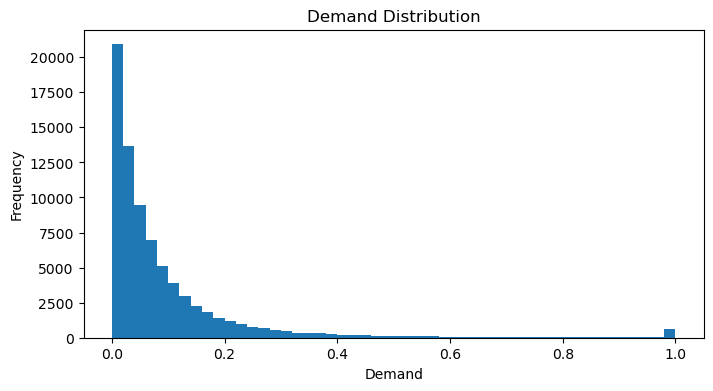

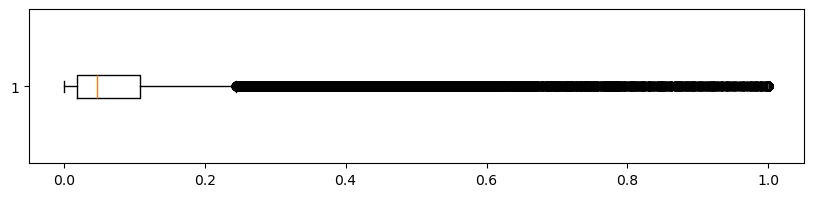

np.float64(3.7285172887316627)

In [7]:
plt.figure(figsize=(8,4))

plt.hist(
    train_df['demand'],
    bins=50
)

plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.title("Demand Distribution")

plt.show()

plt.figure(figsize=(10,2))

plt.boxplot(
    train_df['demand'],
    vert=False
)

plt.show()

train_df['demand'].skew()

In [8]:
train_df['day'].value_counts().sort_index()
sorted(train_df['day'].unique())

[np.int64(48), np.int64(49)]

In [9]:
train_df['geohash'].nunique()

1249

In [10]:
train_df['geohash'].value_counts().head(20)

geohash
qp094q    105
qp03pr    105
qp094r    105
qp03r0    105
qp03r2    105
qp03q9    105
qp03r1    105
qp03r3    105
qp03r9    105
qp03qd    105
qp03qf    105
qp03mg    105
qp03qg    105
qp03r5    105
qp0927    105
qp097e    105
qp092h    105
qp092k    105
qp096u    105
qp097s    105
Name: count, dtype: int64

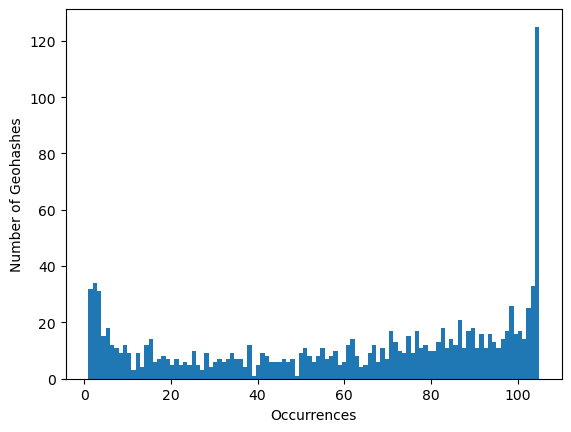

In [11]:
vc = train_df['geohash'].value_counts()

plt.hist(
    vc,
    bins=105
)

plt.xlabel("Occurrences")
plt.ylabel("Number of Geohashes")

plt.show()

In [12]:
train_df['RoadType'].value_counts()

RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64

In [13]:
train_df['RoadType'].value_counts(normalize=True) * 100

RoadType
Residential    90.261933
Street          5.096546
Highway         4.641521
Name: proportion, dtype: float64

In [14]:
road_stats = (
    train_df
    .groupby('RoadType')['demand']
    .describe()
)

road_stats

,count,mean,std,min,25%,50%,75%,max
RoadType,,,,,,,,
Highway,3560.0,0.610756,0.229419,3.500089e-01,0.413629,0.526432,0.790095,1.000000
Residential,69230.0,0.057209,0.052057,6.245650e-07,0.016203,0.040517,0.084468,0.219997
Street,3909.0,0.273164,0.036693,2.200159e-01,0.240702,0.268124,0.301890,0.349908


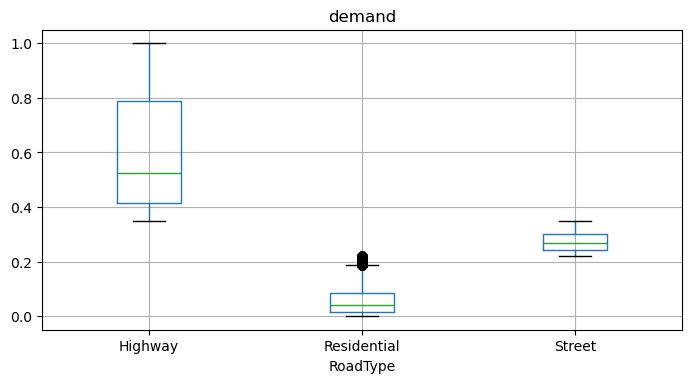

In [15]:
train_df.boxplot(
    column='demand',
    by='RoadType',
    figsize=(8,4)
)

plt.suptitle("")
plt.show()

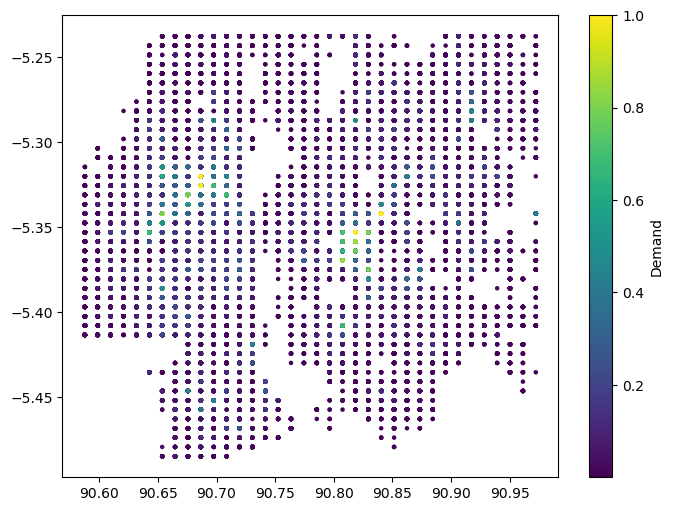

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(
    train_df['lon'],
    train_df['lat'],
    c=train_df['demand'],
    s=5
)
plt.colorbar(label='Demand')
plt.show()


In [16]:
def correlation_ratio(categories, measurements):

    categories = np.array(categories)
    measurements = np.array(measurements)

    cat_codes = pd.Categorical(categories).codes

    grand_mean = measurements.mean()

    ss_between = 0

    for cat in np.unique(cat_codes):

        vals = measurements[cat_codes == cat]

        ss_between += (
            len(vals)
            * (vals.mean() - grand_mean)**2
        )

    ss_total = (
        (measurements - grand_mean)**2
    ).sum()

    return np.sqrt(
        ss_between / ss_total
    )

In [17]:
eta = correlation_ratio(
    train_df['geohash'],
    train_df['demand']
)

print(eta)

0.8332639714109061


In [18]:
geo_map = {
    gh: pgh.decode(gh)
    for gh in train_df['geohash'].unique()
}

train_df['lat'] = train_df['geohash'].map(
    lambda x: geo_map[x][0]
)

train_df['lon'] = train_df['geohash'].map(
    lambda x: geo_map[x][1]
)

In [19]:
train_df[
    ['lat','lon','demand']
].corr()

,lat,lon,demand
lat,1.000000,0.115822,-0.039219
lon,0.115822,1.000000,-0.006807
demand,-0.039219,-0.006807,1.000000


In [20]:
geo_avg = (
    train_df
    .groupby('geohash')['demand']
    .mean()
)

pred = train_df['geohash'].map(
    geo_avg
)

rmse = np.sqrt(
    ((train_df['demand'] - pred)**2)
    .mean()
)

print(rmse)

0.07861312870689148


In [21]:
road_avg = (
    train_df
    .groupby('RoadType')['demand']
    .mean()
)

pred = train_df['RoadType'].map(
    road_avg
)

rmse = np.sqrt(
    ((train_df['demand'] - pred)**2)
    .mean()
)

print(rmse)

0.07040516669586941


In [22]:
pred = (
    train_df
    .groupby(
        ['RoadType','geohash']
    )['demand']
    .transform('mean')
)

rmse = np.sqrt(
    (
        (train_df['demand'] - pred)**2
    ).mean()
)

print(rmse)

0.048331640200270067


In [23]:
geohash_counts = train_df["geohash"].value_counts()

print((geohash_counts == 1).sum())
print((geohash_counts <= 5).sum())

32
130


In [26]:
train_df['NumberofLanes'].value_counts()

NumberofLanes
1    27411
2    24127
3    23919
4      926
5      916
Name: count, dtype: int64

In [28]:
# Select only numeric columns
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

# Correlation with demand
corr_with_demand = (
    train_df[numeric_cols]
    .corr()['demand']
    .sort_values(ascending=False)
)

print(corr_with_demand)

demand           1.000000
NumberofLanes    0.214148
day              0.026807
Temperature      0.003144
Index           -0.001481
lon             -0.006807
lat             -0.039219
Name: demand, dtype: float64


In [29]:
train_df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,lat,lon
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,-5.484924,90.664673
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,-5.462952,90.686646
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,-5.462952,90.708618
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,-5.462952,90.862427
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,-5.457458,90.675659


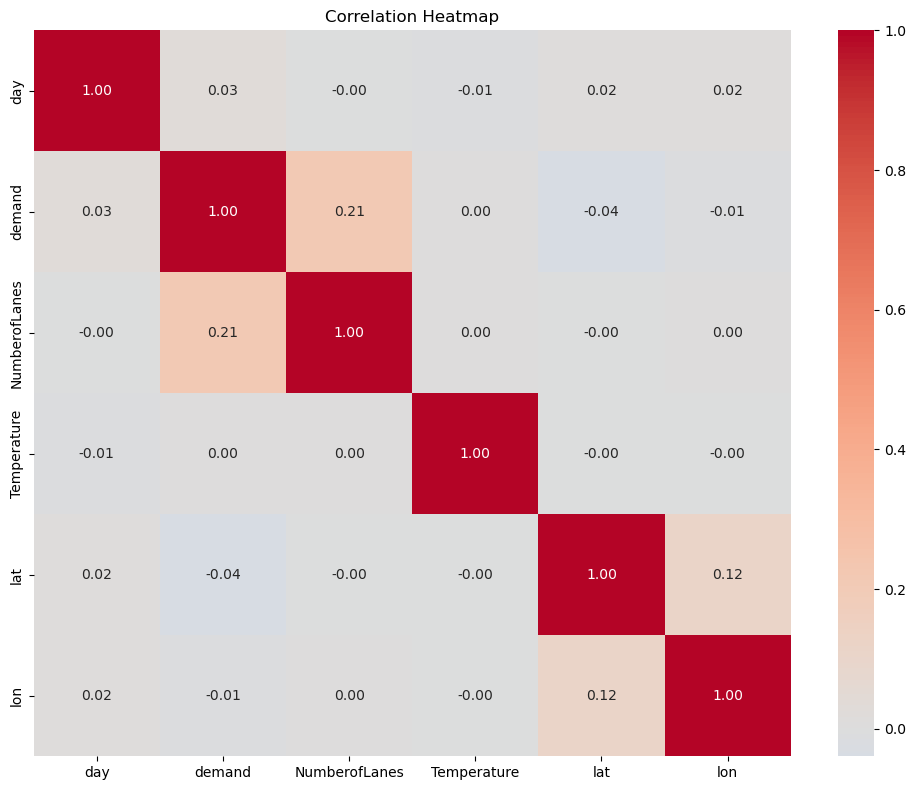

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns only
numeric_df = train_df.select_dtypes(include=[np.number])
numeric_df.drop(columns=['Index'], inplace=True)
# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
train_df['']